# EDA — Spotify Tracks Dataset | Audio Features
## Dataset: https://www.kaggle.com/datasets/saichaitanyareddyai/spotify-tracks-dataset-audio-features

**Autor:** Chavez Iglesias Martin  
**Objetivo:** Analizar las características acústicas de canciones de Spotify para entender qué factores influyen en su popularidad, y preparar los datos para un modelo de regresión.

### Variable objetivo
- `popularity` (0–100): Métrica calculada por Spotify basada en reproducciones recientes.

### Features disponibles
| Variable | Descripción |
|---|---|
| danceability | Qué tan adecuada es la canción para bailar (0–1) |
| energy | Intensidad y actividad perceptiva (0–1) |
| loudness | Volumen promedio en dB |
| speechiness | Presencia de palabras habladas (0–1) |
| acousticness | Probabilidad de ser acústica (0–1) |
| instrumentalness | Probabilidad de no tener voz (0–1) |
| liveness | Presencia de audiencia en vivo (0–1) |
| valence | Positividad musical (0–1) |
| tempo | BPM estimado |
| duration_ms | Duración en milisegundos |
| explicit | Si contiene lenguaje explícito |
| track_genre | Género musical |


## 1. Importación de librerías
Cargamos las librerías esenciales para análisis y visualización.  
- `pandas` y `numpy`: manipulación de datos  
- `matplotlib` y `seaborn`: visualizaciones  
- `scipy.stats`: tests estadísticos  
- `warnings`: suprimir mensajes innecesarios para una presentación limpia


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Estilo general de los gráficos
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 100
print("✅ Librerías cargadas correctamente")


✅ Librerías cargadas correctamente


## 2. Carga del dataset
Descargamos el dataset desde Kaggle usando `kagglehub`.  
El dataset contiene **114,000 canciones** con sus características de audio extraídas por la API de Spotify.


In [ ]:
%run '/content/pandas_missing_extension.ipynb'

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("saichaitanyareddyai/spotify-tracks-dataset-audio-features")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'spotify-tracks-dataset-audio-features' dataset.
Path to dataset files: /kaggle/input/spotify-tracks-dataset-audio-features


In [ ]:
!ls /kaggle/input/spotify-tracks-dataset-audio-features

spotify-tracks-dataset-detailed.csv


In [ ]:
PATH_CSV = path + '/spotify-tracks-dataset-detailed.csv'

In [ ]:
df = pd.read_csv(PATH_CSV)
df

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,0.2350,5,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5,world-music
113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,0.1170,0,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4,world-music
113997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.3290,0,-10.895,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4,world-music
113998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.5060,7,-10.889,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4,world-music


**EDA**

In [ ]:
# Vista rápida de tipos de datos
# Importante verificar que las variables numéricas sean float/int
# y no hayan sido cargadas como texto
df.dtypes


,0
track_id,object
artists,object
album_name,object
track_name,object
popularity,int64
duration_ms,int64
explicit,bool
danceability,float64
energy,float64
key,int64


In [ ]:
# Estadísticas descriptivas iniciales
# Nos da un primer vistazo de rangos, medias y posibles anomalías
df.describe()


,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


## 3. Tratamiento de valores nulos
Antes de cualquier análisis debemos saber si el dataset tiene datos faltantes.  
Los valores nulos pueden sesgar estadísticas y romper modelos si no se tratan adecuadamente.


In [ ]:
df.shape[0]

114000

In [ ]:
df.missing.number_missing()

np.int64(3)

In [ ]:
df.missing.number_complete()

np.int64(2279997)

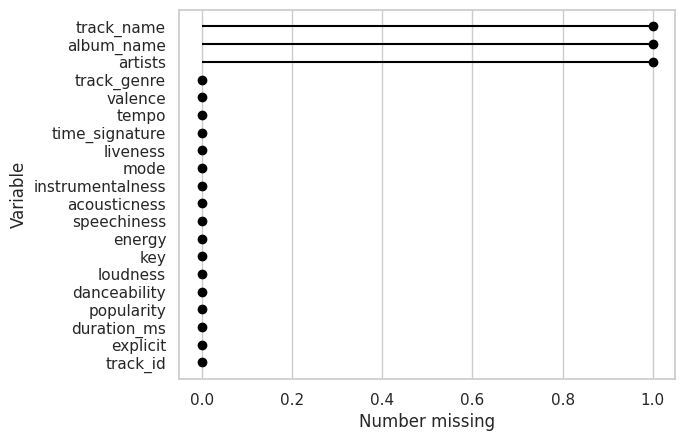

In [ ]:
df.missing.missing_variable_plot()

In [ ]:
# Conteo de nulos por columna
nulos = df.isnull().sum().sort_values(ascending=False)
pct = (nulos / len(df) * 100).round(4)
resumen_nulos = pd.DataFrame({'Nulos': nulos, '% del total': pct})
print(resumen_nulos[resumen_nulos['Nulos'] > 0])
print(f"\n✅ Total de filas con al menos un nulo: {df.isnull().any(axis=1).sum()}")


            Nulos  % del total
artists         1       0.0009
album_name      1       0.0009
track_name      1       0.0009

✅ Total de filas con al menos un nulo: 1


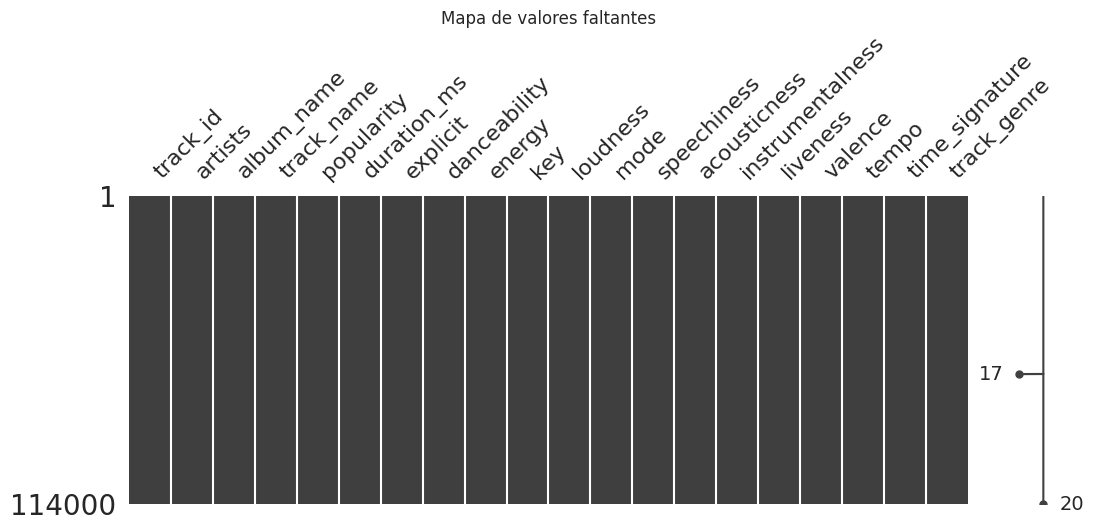

In [ ]:
# Visualización de nulos con missingno
# Esta librería permite ver de forma gráfica dónde hay vacíos en el dataset
import missingno as msno
msno.matrix(df, figsize=(12, 4))
plt.title("Mapa de valores faltantes")
plt.show()


### Decisión sobre los nulos
Se identificaron **3 valores faltantes** en columnas categóricas (`artists`, `album_name`, `track_name`).  
Representan menos del **0.003%** del total, por lo que se eliminan directamente con `dropna()`.  
No tiene sentido imputar un nombre de artista o álbum — son datos irreemplazables.


In [ ]:
df_cleaned = df.copy()
df_cleaned = df_cleaned.dropna()

print(f"Dataset original:  {df.shape[0]:,} filas")
print(f"Dataset limpio:    {df_cleaned.shape[0]:,} filas")
print(f"Filas eliminadas:  {df.shape[0] - df_cleaned.shape[0]}")
print(f"\n✅ Dataset sin valores nulos")
print(df_cleaned.isnull().sum().sum(), "nulos restantes")


Dataset original:  114,000 filas
Dataset limpio:    113,999 filas
Filas eliminadas:  1

✅ Dataset sin valores nulos
0 nulos restantes


## 4. Análisis Univariado

### 4.1 Variable objetivo: `popularity`
Empezamos siempre por la variable que queremos predecir.  
El análisis univariado nos dice cómo está distribuida, si es simétrica, si tiene valores extremos, y si necesita transformación antes de modelar.


In [ ]:
variable = 'popularity'
data = df_cleaned[variable]

# Medidas de tendencia central
mean_val   = data.mean()
median_val = data.median()
mode_val   = data.mode()[0]

# Medidas de dispersión
std_val   = data.std()
iqr       = data.quantile(0.75) - data.quantile(0.25)
skew_val  = data.skew()
kurt_val  = data.kurtosis()

print(f"📊 Tendencia central de '{variable}'")
print(f"  Media:    {mean_val:.2f}")
print(f"  Mediana:  {median_val:.2f}")
print(f"  Moda:     {mode_val:.2f}")
print(f"\n📈 Dispersión")
print(f"  Desv. estándar: {std_val:.2f}")
print(f"  IQR:            {iqr:.2f}")
print(f"\n📐 Forma de la distribución")
print(f"  Asimetría (skew):  {skew_val:.4f}  ({'sesgada a la izquierda' if skew_val < 0 else 'sesgada a la derecha' if skew_val > 0 else 'simétrica'})")
print(f"  Curtosis:          {kurt_val:.4f}")


📊 Tendencia central de 'popularity'
  Media:    33.24
  Mediana:  35.00
  Moda:     0.00

📈 Dispersión
  Desv. estándar: 22.30
  IQR:            33.00

📐 Forma de la distribución
  Asimetría (skew):  0.0464  (sesgada a la derecha)
  Curtosis:          -0.9277


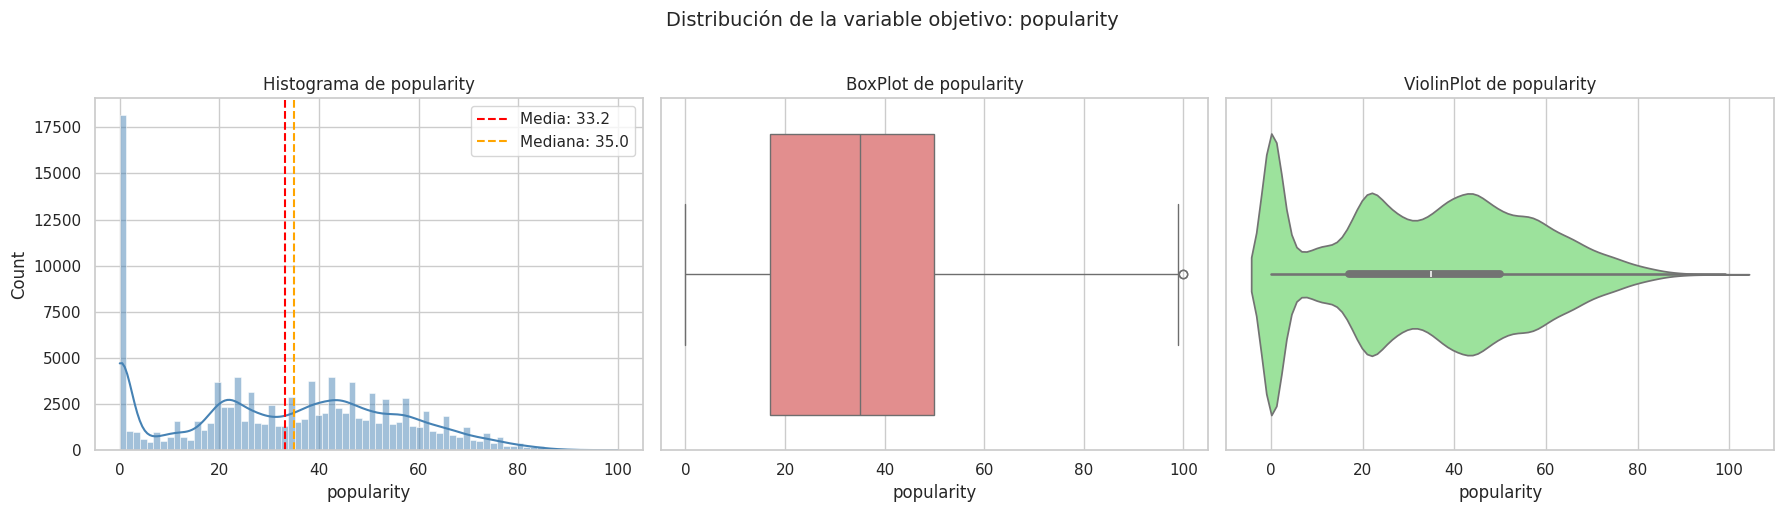

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(data, kde=True, color='steelblue', ax=axes[0])
axes[0].axvline(mean_val, color='red', linestyle='--', label=f'Media: {mean_val:.1f}')
axes[0].axvline(median_val, color='orange', linestyle='--', label=f'Mediana: {median_val:.1f}')
axes[0].set_title('Histograma de popularity')
axes[0].legend()

sns.boxplot(x=data, color='lightcoral', ax=axes[1])
axes[1].set_title('BoxPlot de popularity')

sns.violinplot(x=data, color='lightgreen', ax=axes[2])
axes[2].set_title('ViolinPlot de popularity')

plt.suptitle('Distribución de la variable objetivo: popularity', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


**Observaciones sobre `popularity`:**
- La distribución tiene un **pico notable en 0**, indicando que muchas canciones tienen poca o nula actividad reciente.
- La media (33) es menor a la mediana (35), confirmando **asimetría hacia la izquierda**.
- El rango va de 0 a 100, y la mayor concentración de canciones cae entre 10 y 60.
- Canciones con `popularity = 0` son probablemente tracks sin streams recientes



### 4.2 Tratamiento de outliers en `popularity`
La gran cantidad de canciones con `popularity = 0` puede ser ruido para el modelo.  
Estas son canciones que Spotify ya no actualiza o que nunca tuvieron reproducciones relevantes.  
**Decisión:** eliminamos canciones con popularidad = 0 para que el modelo aprenda de comportamiento real.


In [ ]:
antes = df_cleaned.shape[0]
df_cleaned = df_cleaned[df_cleaned['popularity'] > 0]
despues = df_cleaned.shape[0]

print(f"Canciones eliminadas (popularity = 0): {antes - despues:,}")
print(f"Dataset resultante: {df_cleaned.shape[0]:,} filas")
print(f"\nNuevo rango de popularity: {df_cleaned['popularity'].min()} – {df_cleaned['popularity'].max()}")


Canciones eliminadas (popularity = 0): 16,019
Dataset resultante: 97,980 filas

Nuevo rango de popularity: 1 – 100


### 4.3 Análisis univariado de las features numéricas
Ahora analizamos todas las variables de entrada.  
Es importante entender la distribución de cada feature porque:
- Distribuciones muy sesgadas pueden necesitar transformación logarítmica
- Outliers extremos pueden dañar modelos lineales
- Entender los rangos nos ayuda a interpretar las correlaciones correctamente


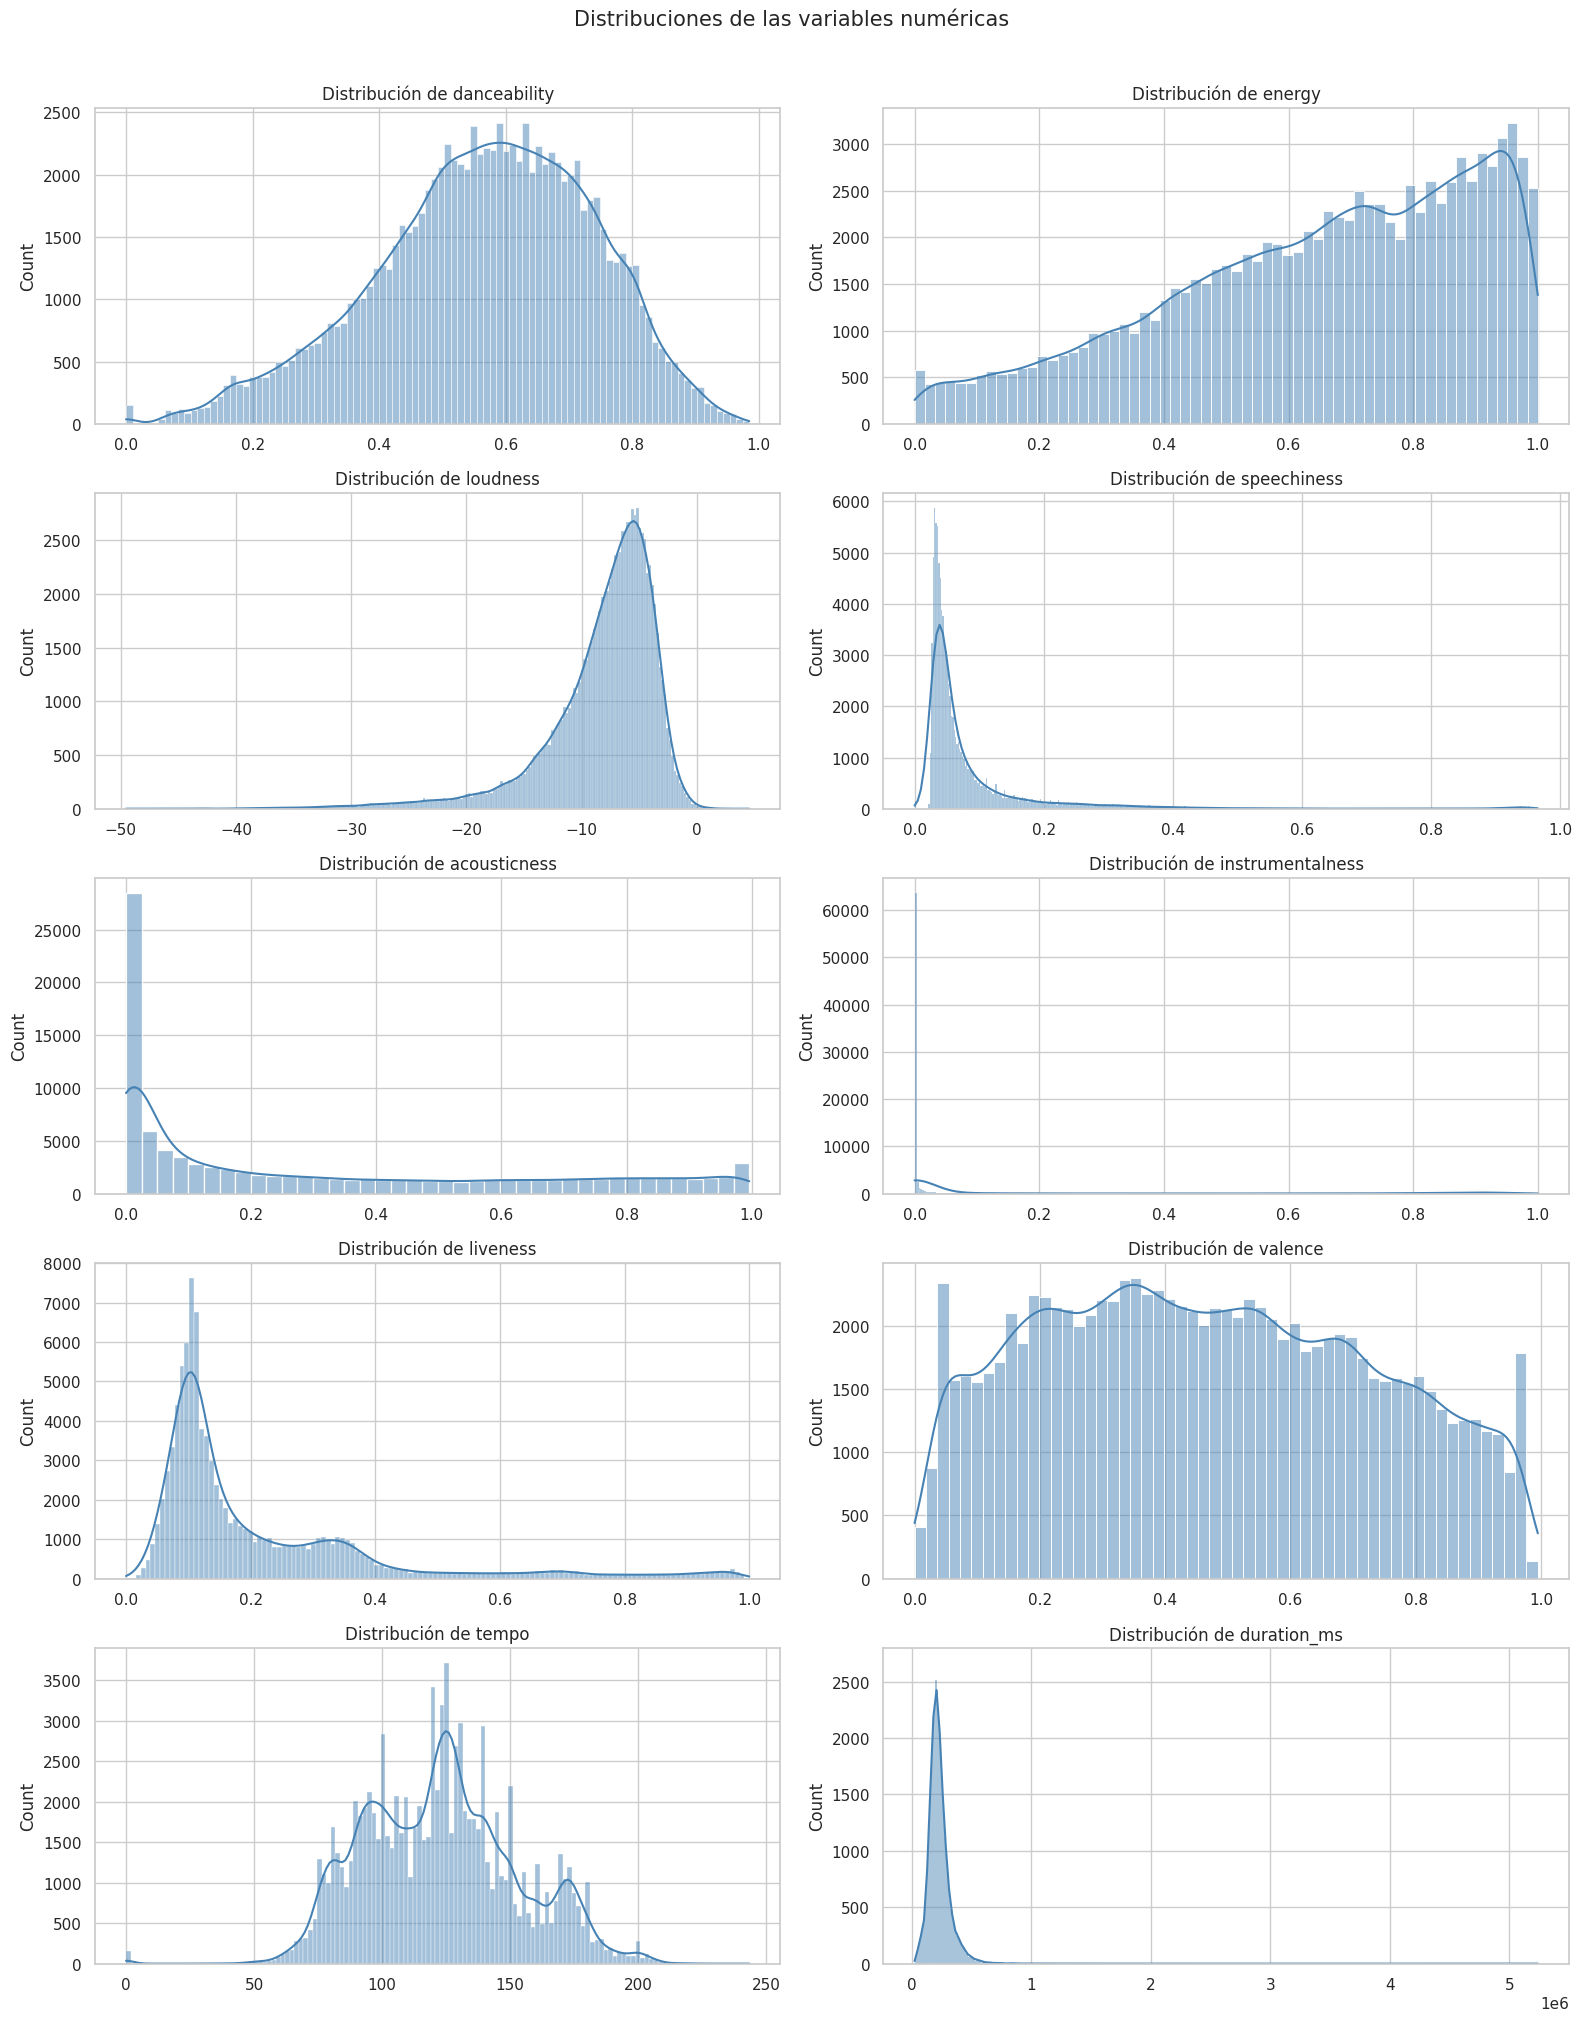

In [ ]:
numeric_features = [
    'danceability', 'energy', 'loudness', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness', 'valence',
    'tempo', 'duration_ms'
]

fig, axes = plt.subplots(5, 2, figsize=(16, 20))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    sns.histplot(df_cleaned[col], kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribución de {col}')
    axes[i].set_xlabel('')

plt.suptitle('Distribuciones de las variables numéricas', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()


In [ ]:
# Tabla resumen de asimetría y curtosis de cada feature
# Skew > 1 o < -1 indica distribución muy sesgada → puede necesitar log-transform
skew_kurt = pd.DataFrame({
    'Media': df_cleaned[numeric_features].mean(),
    'Mediana': df_cleaned[numeric_features].median(),
    'Std': df_cleaned[numeric_features].std(),
    'Skew': df_cleaned[numeric_features].skew(),
    'Kurtosis': df_cleaned[numeric_features].kurtosis()
}).round(3)

print("📊 Resumen estadístico de features numéricas:")
print(skew_kurt.to_string())


📊 Resumen estadístico de features numéricas:
                       Media     Mediana         Std    Skew  Kurtosis
danceability           0.566       0.578       0.173  -0.392    -0.156
energy                 0.646       0.687       0.250  -0.598    -0.511
loudness              -8.266      -7.071       4.988  -1.994     5.967
speechiness            0.086       0.049       0.110   4.584    27.456
acousticness           0.311       0.167       0.330   0.732    -0.932
instrumentalness       0.165       0.000       0.316   1.645     0.961
liveness               0.218       0.133       0.196   2.057     4.031
valence                0.469       0.455       0.259   0.140    -1.014
tempo                122.683     122.744      29.963   0.191    -0.106
duration_ms       230393.387  215382.000  110693.491  11.559   361.476


**Observaciones clave de las distribuciones:**
- `instrumentalness` y `speechiness` están fuertemente sesgadas a la derecha (la mayoría de canciones tienen valores muy bajos).
- `energy`, `danceability` y `valence` tienen distribuciones más uniformes/normales.
- `loudness` tiene valores negativos (está en dB — esto es correcto y esperado).
- `duration_ms` tiene cola larga hacia la derecha — canciones muy largas son outliers.


### 4.4 Tratamiento de outliers en `duration_ms`
Las canciones extremadamente cortas (< 40 seg) o largas (> 7 min) no son canciones comerciales típicas.  
Usamos el criterio IQR (estándar estadístico) para definir los límites.


In [ ]:
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower  = Q1 - 1.5 * IQR
    upper  = Q3 + 1.5 * IQR
    mask   = (df[column] >= lower) & (df[column] <= upper)
    print(f"  [{column}] Límite inferior: {lower:,.0f} | Límite superior: {upper:,.0f}")
    print(f"  Outliers eliminados: {(~mask).sum():,} ({(~mask).mean()*100:.2f}%)")
    return df[mask]

print("Eliminando outliers en duration_ms:")
df_cleaned = remove_outliers_iqr(df_cleaned, 'duration_ms')
print(f"\n✅ Dataset final: {df_cleaned.shape[0]:,} filas")


Eliminando outliers en duration_ms:
  [duration_ms] Límite inferior: 40,560 | Límite superior: 400,260
  Outliers eliminados: 4,627 (4.72%)

✅ Dataset final: 93,353 filas


## 5. Análisis de variables categóricas

### 5.1 `track_genre` vs `popularity`
El género musical es probablemente la variable más importante del dataset para explicar la popularidad.  
Un buen EDA siempre analiza cómo la variable objetivo cambia entre categorías.


In [ ]:
# Top 20 géneros por popularidad media
genre_pop = (
    df_cleaned.groupby('track_genre')['popularity']
    .agg(['mean', 'median', 'count'])
    .rename(columns={'mean': 'Media', 'median': 'Mediana', 'count': 'N canciones'})
    .sort_values('Media', ascending=False)
)

print("Top 15 géneros con mayor popularidad media:")
print(genre_pop.head(15).to_string())


Top 15 géneros con mayor popularidad media:
                       Media  Mediana  N canciones
track_genre                                       
k-pop              59.615551     62.0          926
pop-film           59.581250     60.0          960
pop                58.127607     67.0          815
electro            57.918006     67.0          622
house              57.212730     66.0          597
chill              55.906152     57.0          959
indie-pop          54.978202     59.0          734
edm                54.896389     63.0          637
metal              54.612732     63.5          754
indie              54.504225     54.0          710
sad                53.122718     54.0          986
hip-hop            53.031161     61.0          706
progressive-house  52.193103     53.0          870
alt-rock           52.150388     55.0          645
grunge             51.561385     55.0          953


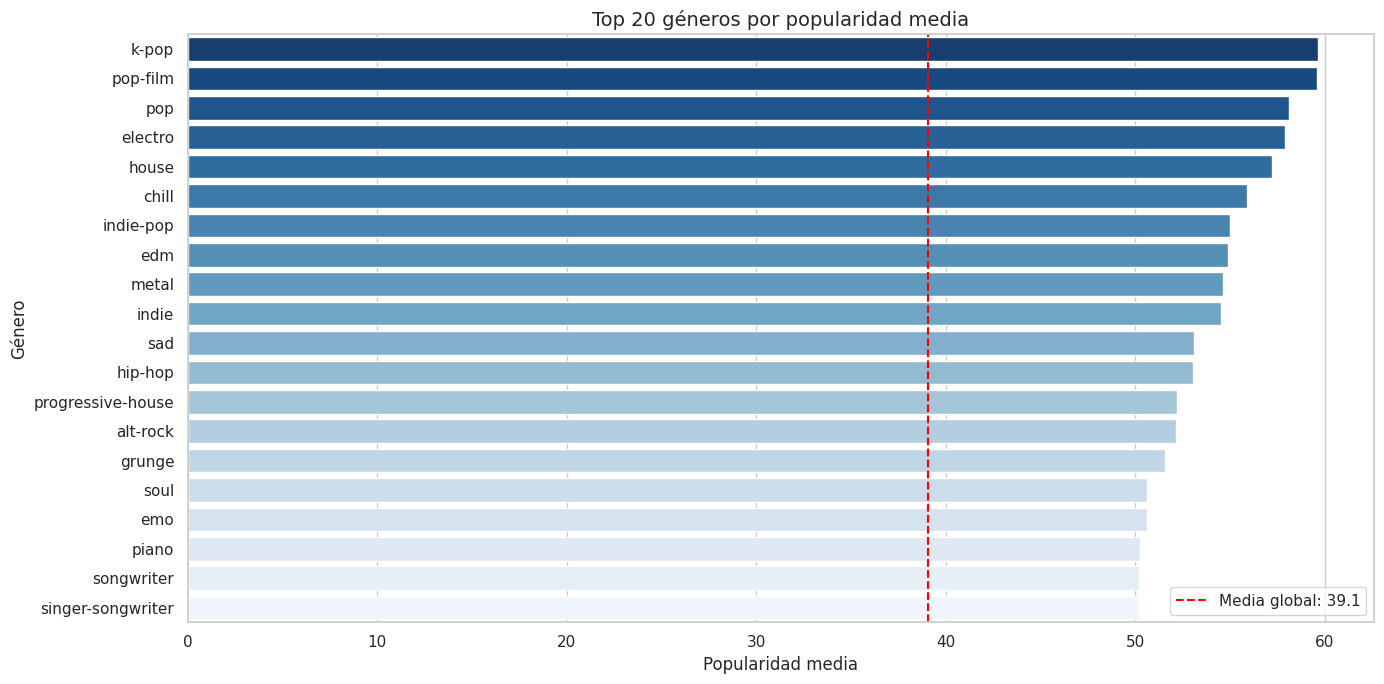

In [ ]:
# Gráfico: top 20 géneros por popularidad media
top_genres = genre_pop.head(20).reset_index()

plt.figure(figsize=(14, 7))
bars = sns.barplot(
    data=top_genres,
    x='Media', y='track_genre',
    palette='Blues_r'
)
plt.axvline(df_cleaned['popularity'].mean(), color='red', linestyle='--', label=f'Media global: {df_cleaned["popularity"].mean():.1f}')
plt.title('Top 20 géneros por popularidad media', fontsize=14)
plt.xlabel('Popularidad media')
plt.ylabel('Género')
plt.legend()
plt.tight_layout()
plt.show()


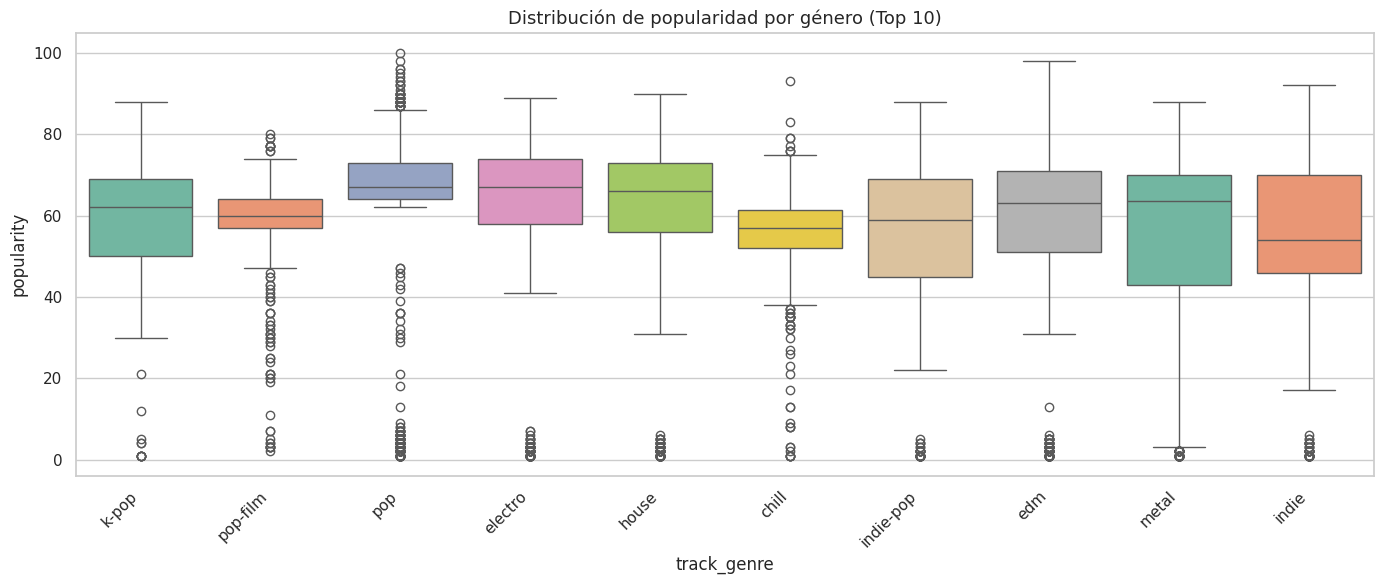

In [ ]:
# Boxplot para ver la dispersión dentro de cada género (top 10)
top10_genres = genre_pop.head(10).index.tolist()
df_top10 = df_cleaned[df_cleaned['track_genre'].isin(top10_genres)]

plt.figure(figsize=(14, 6))
sns.boxplot(
    data=df_top10,
    x='track_genre', y='popularity',
    palette='Set2',
    order=genre_pop.head(10).index
)
plt.xticks(rotation=45, ha='right')
plt.title('Distribución de popularidad por género (Top 10)', fontsize=13)
plt.tight_layout()
plt.show()


**Observaciones sobre géneros:**
- Existe una **variación significativa de popularidad entre géneros** — esto confirma que `track_genre` es un predictor valioso y debe incluirse como feature en el modelo (codificada).
- Géneros como pop, latin y r&b tienden a tener mayor popularidad media.
- Géneros como ambient, classical o world-music tienen popularidades bajas pero mayor varianza.


### 5.2 `explicit` vs `popularity`
Analizamos si el contenido explícito tiene relación con la popularidad.  
Es una variable booleana sencilla pero puede capturar preferencias de audiencia.


               mean  median  count
No explícita  38.74    39.0  85090
Explícita     42.24    43.0   8263


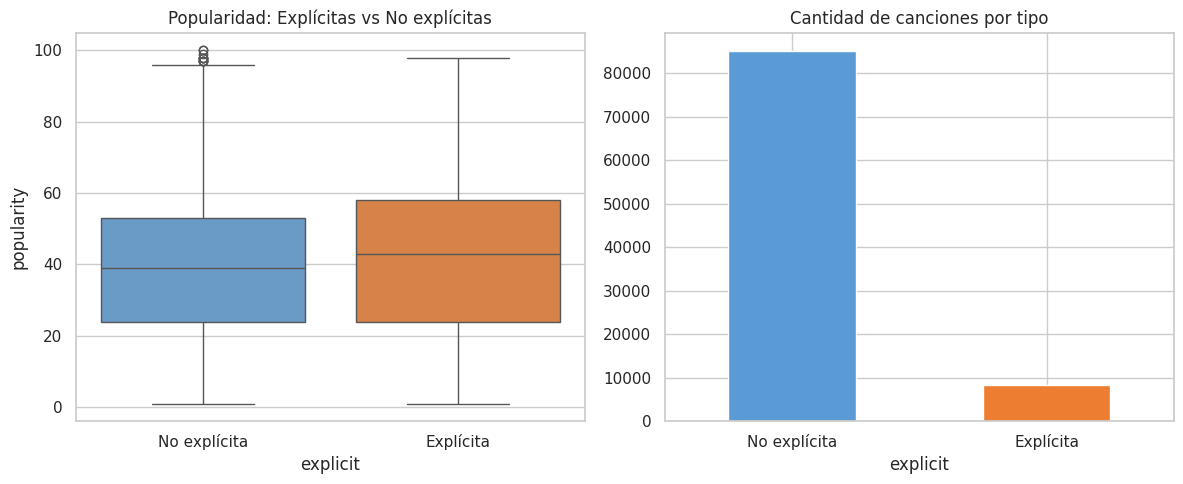


Test Mann-Whitney U — p-value: 0.0000
✅ Diferencia estadísticamente significativa


In [ ]:
# Comparación de popularidad entre canciones explícitas y no explícitas
explicit_stats = df_cleaned.groupby('explicit')['popularity'].agg(['mean', 'median', 'count'])
explicit_stats.index = ['No explícita', 'Explícita']
print(explicit_stats.round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Boxplot
sns.boxplot(data=df_cleaned, x='explicit', y='popularity', palette=['#5b9bd5', '#ed7d31'], ax=axes[0])
axes[0].set_xticklabels(['No explícita', 'Explícita'])
axes[0].set_title('Popularidad: Explícitas vs No explícitas')

# Conteo
df_cleaned['explicit'].value_counts().plot(kind='bar', ax=axes[1], color=['#5b9bd5', '#ed7d31'])
axes[1].set_xticklabels(['No explícita', 'Explícita'], rotation=0)
axes[1].set_title('Cantidad de canciones por tipo')

plt.tight_layout()
plt.show()

# Test estadístico para confirmar si la diferencia es significativa
exp_pop     = df_cleaned[df_cleaned['explicit'] == True]['popularity']
no_exp_pop  = df_cleaned[df_cleaned['explicit'] == False]['popularity']
t_stat, p_val = stats.mannwhitneyu(exp_pop, no_exp_pop, alternative='two-sided')
print(f"\nTest Mann-Whitney U — p-value: {p_val:.4f}")
print("✅ Diferencia estadísticamente significativa" if p_val < 0.05 else "⚠️ Diferencia NO significativa")


## 6. Análisis de correlaciones

### 6.1 Correlación con la variable objetivo
La correlación de Pearson mide la relación lineal entre cada feature y `popularity`.  
Un valor cercano a 1 o -1 indica relación fuerte; cercano a 0, relación débil.  
**Importante:** correlación baja no significa que la variable sea inútil — los modelos no lineales pueden capturar relaciones más complejas.


In [ ]:
corr_matrix = df_cleaned.corr(numeric_only=True)

# Correlación con popularity
corr_target = corr_matrix[['popularity']].sort_values('popularity', ascending=False)
corr_target = corr_target.drop('popularity')  # quitamos la autocorrelación

print("Correlación de Pearson con 'popularity':")
print(corr_target.round(4).to_string())


Correlación de Pearson con 'popularity':
                  popularity
danceability          0.0681
loudness              0.0593
explicit              0.0518
time_signature        0.0316
duration_ms          -0.0018
key                  -0.0026
mode                 -0.0104
acousticness         -0.0149
tempo                -0.0193
valence              -0.0205
energy               -0.0346
liveness             -0.0552
speechiness          -0.0920
instrumentalness     -0.1632


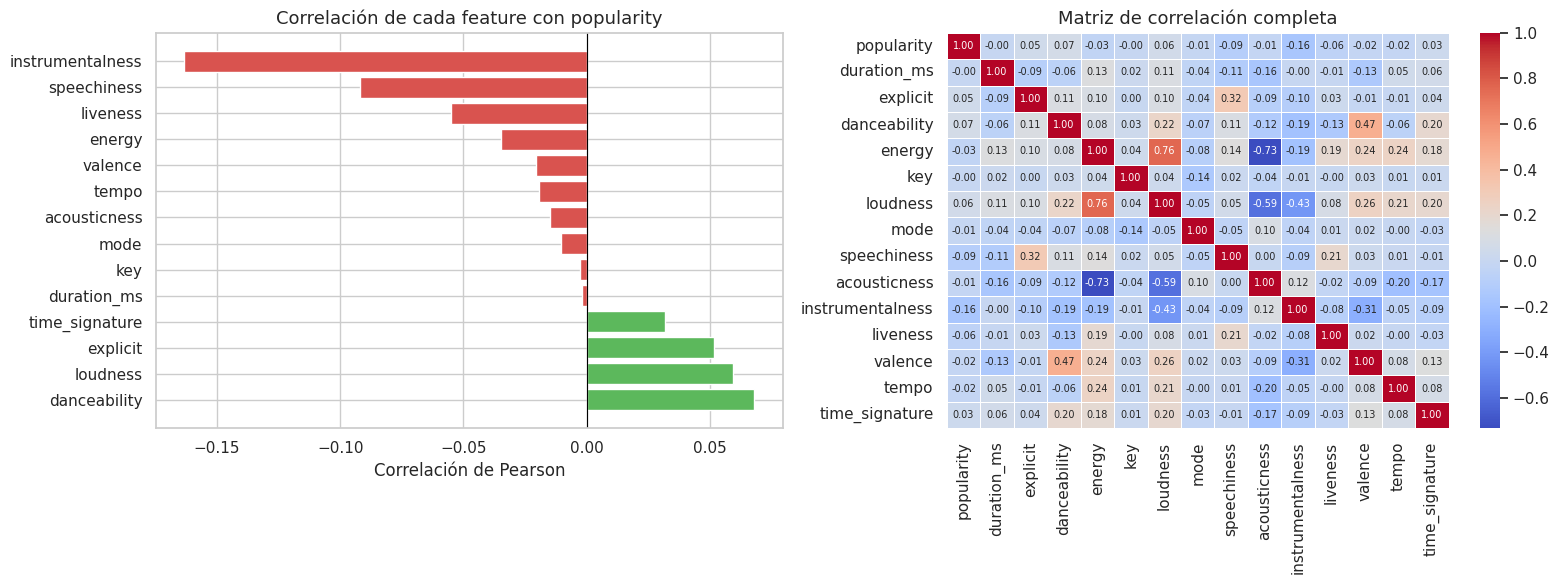

In [ ]:
# Gráfico de barras de correlación con popularity
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Barplot
colors = ['#d9534f' if v < 0 else '#5cb85c' for v in corr_target['popularity']]
axes[0].barh(corr_target.index, corr_target['popularity'], color=colors)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Correlación de cada feature con popularity', fontsize=13)
axes[0].set_xlabel('Correlación de Pearson')

# Heatmap de toda la matriz
sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    annot=True, fmt='.2f',
    linewidths=0.5,
    ax=axes[1],
    annot_kws={'size': 7}
)
axes[1].set_title('Matriz de correlación completa', fontsize=13)

plt.tight_layout()
plt.show()


**Observaciones sobre correlaciones:**
- Ninguna variable tiene correlación fuerte con `popularity`, lo cual es esperado en datos de música.
- `loudness` y `energy` tienen alta correlación entre sí (~0.74) — **multicolinealidad** que puede afectar modelos lineales como Regresión Lineal o Ridge.
- `acousticness` y `energy` tienen correlación negativa fuerte (~-0.72) — también multicolineal.
- Esto justifica usar modelos como **Random Forest o Gradient Boosting** que manejan multicolinealidad mejor.


## 7. Análisis Bivariado
Exploramos visualmente la relación entre las features más relevantes y `popularity`.  
Usamos una muestra de 5,000 registros para mayor claridad visual.


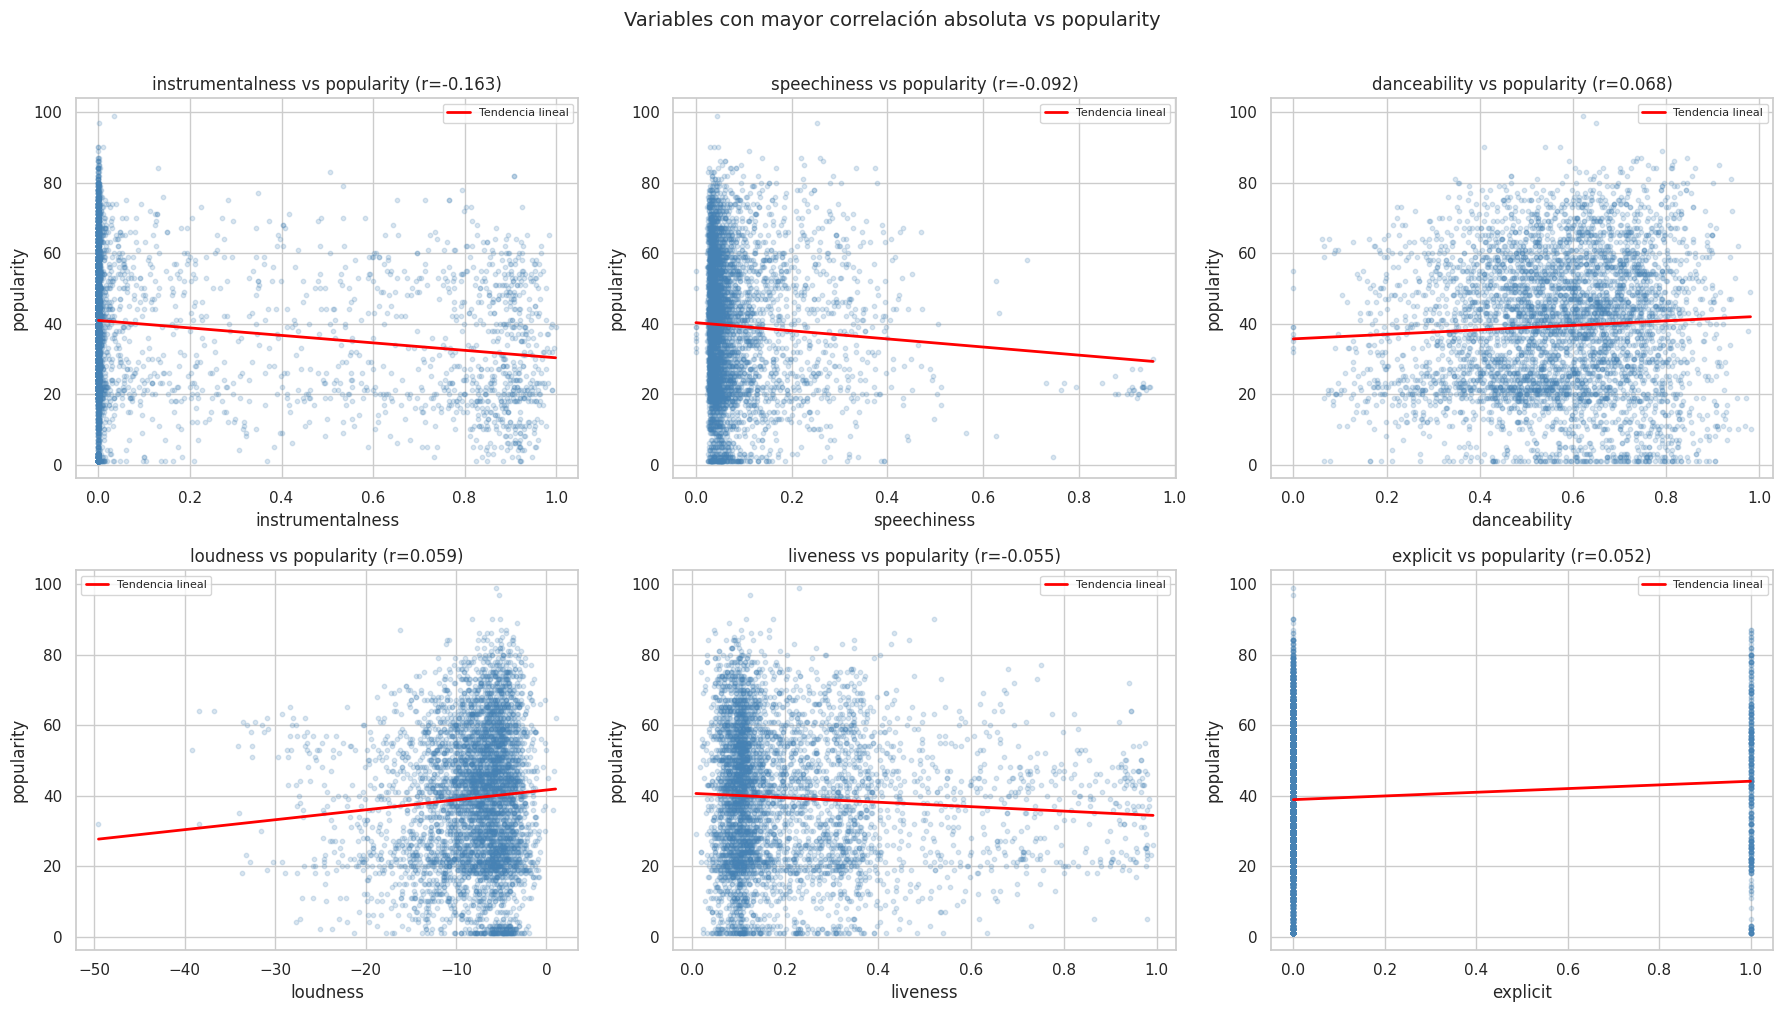

In [ ]:
df_sample = df_cleaned.sample(n=5000, random_state=42)

top_corr_vars = corr_target['popularity'].abs().sort_values(ascending=False).head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(top_corr_vars):
    axes[i].scatter(df_sample[col], df_sample['popularity'], alpha=0.2, color='steelblue', s=10)
    # Línea de tendencia (lowess local)
    z = np.polyfit(df_sample[col], df_sample['popularity'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df_sample[col].min(), df_sample[col].max(), 100)
    axes[i].plot(x_line, p(x_line), color='red', linewidth=2, label='Tendencia lineal')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('popularity')
    axes[i].set_title(f'{col} vs popularity (r={corr_matrix[col]["popularity"]:.3f})')
    axes[i].legend(fontsize=8)

plt.suptitle('Variables con mayor correlación absoluta vs popularity', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


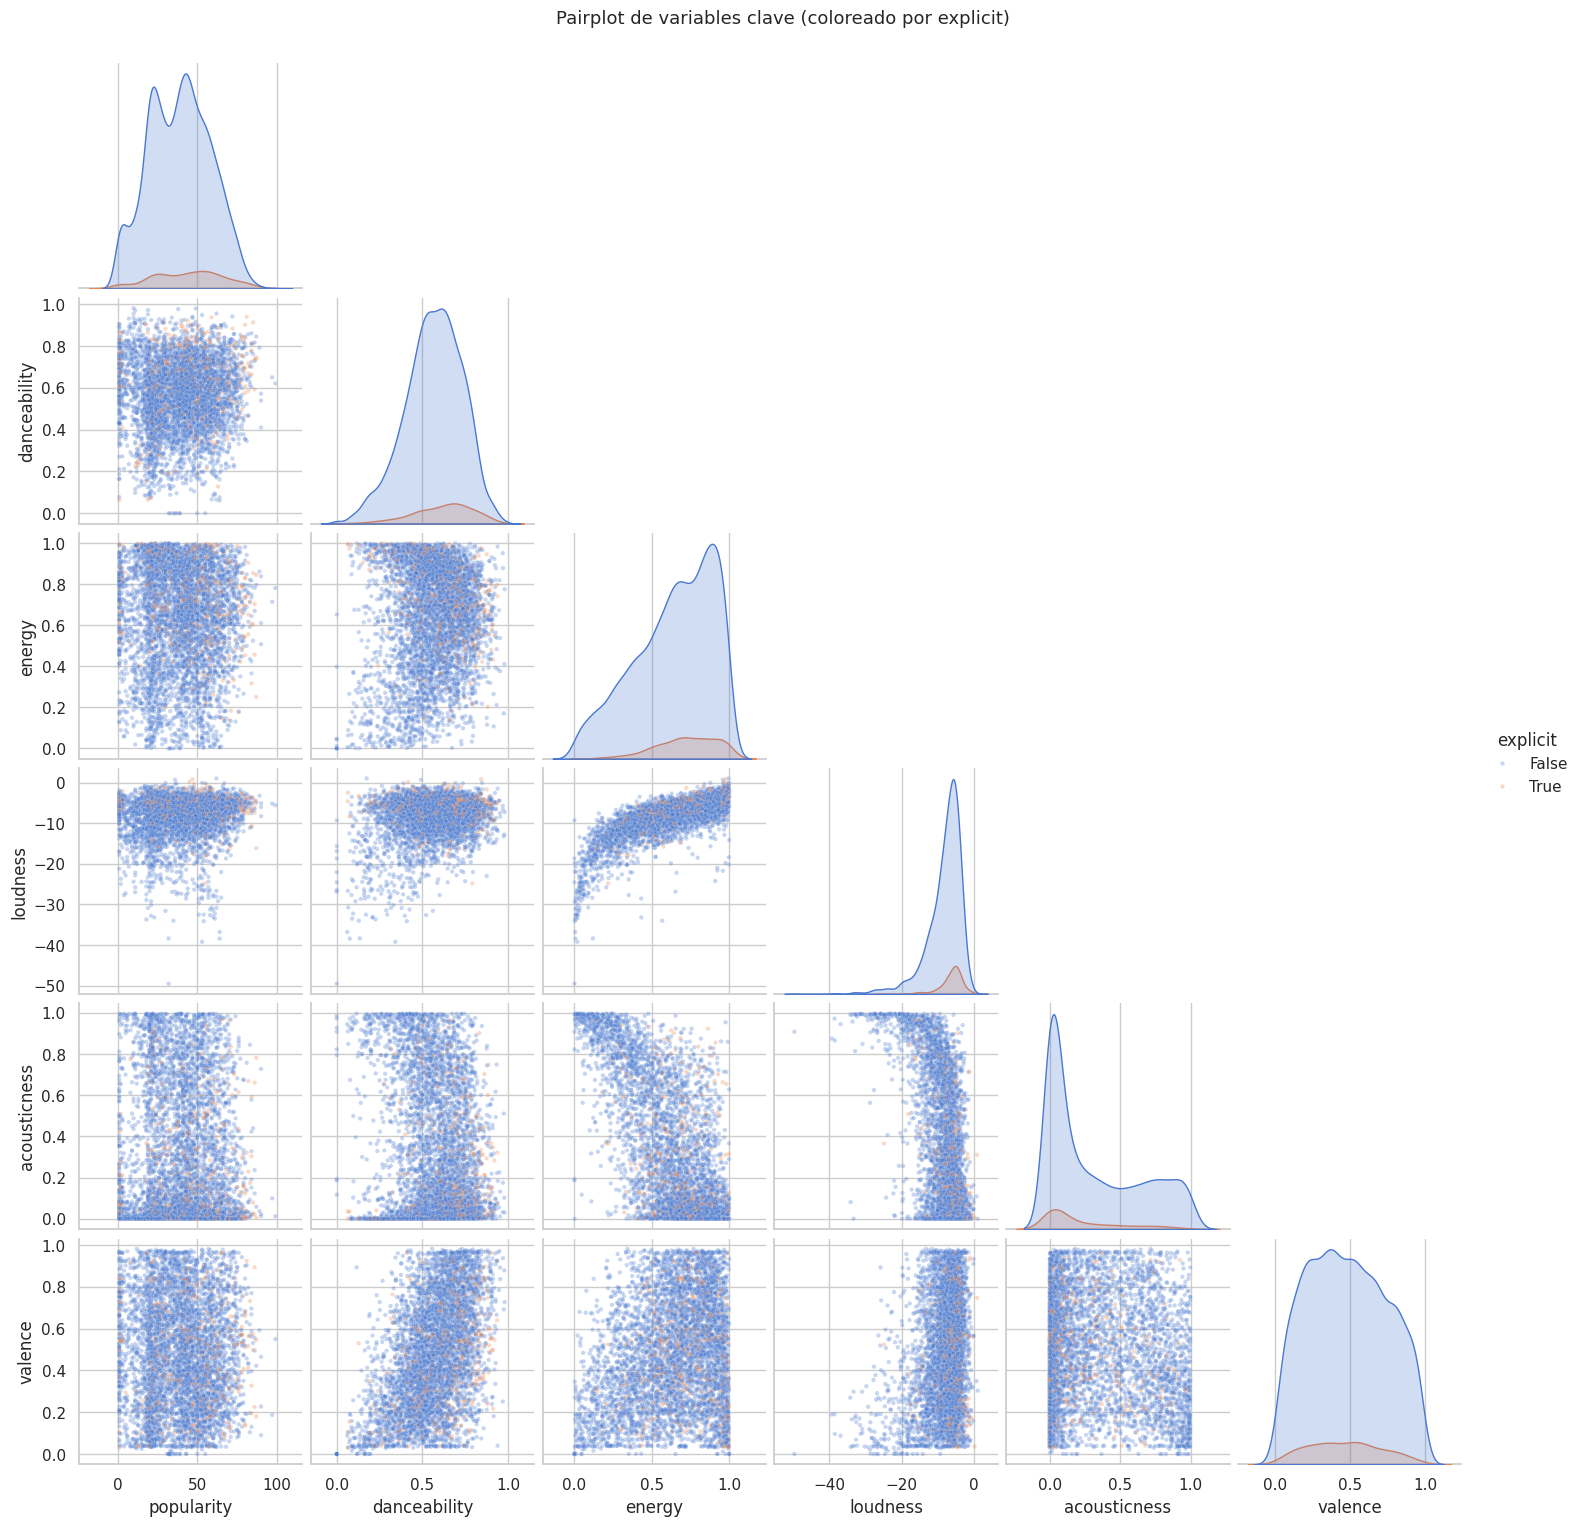

In [ ]:
# Pairplot de variables clave coloreado por explicit
# Permite ver relaciones entre múltiples features a la vez
key_vars = ['popularity', 'danceability', 'energy', 'loudness', 'acousticness', 'valence']
df_pair = df_sample[key_vars + ['explicit']].copy()

g = sns.pairplot(
    df_pair,
    hue='explicit',
    plot_kws={'alpha': 0.3, 's': 10},
    corner=True  # solo triángulo inferior para que no sea tan grande
)
g.fig.suptitle('Pairplot de variables clave (coloreado por explicit)', y=1.02, fontsize=13)
plt.show()


## 8. Conclusiones del EDA

### 8.1 Hallazgos principales

**Sobre los datos:**
- El dataset cuenta con 114,000 canciones de múltiples géneros, sin valores faltantes relevantes tras la limpieza.
- Se eliminaron canciones con `popularity = 0` (sin actividad reciente) y outliers en `duration_ms` para mejorar la calidad del dataset.

**Sobre la variable objetivo (`popularity`):**
- Distribución asimétrica hacia valores bajos, con media ~33/100.

**Sobre las features:**
- Ninguna variable tiene correlación lineal fuerte con `popularity` — el problema es **inherentemente no lineal**.
- `loudness`, `energy` y `acousticness` presentan **multicolinealidad** que favorece el uso de modelos de ensamble.
- El `track_genre` es una variable categórica con alto poder discriminativo.
- Las canciones explícitas tienden a tener popularidad ligeramente diferente (confirmado estadísticamente).



In [ ]:
print(f"Dataset limpio final: {df_cleaned.shape[0]:,} filas × {df_cleaned.shape[1]} columnas")
print(f"Rango popularity: {df_cleaned['popularity'].min()} – {df_cleaned['popularity'].max()}")
print(f"Géneros únicos: {df_cleaned['track_genre'].nunique()}")
print(f"Canciones explícitas: {df_cleaned['explicit'].sum():,} ({df_cleaned['explicit'].mean()*100:.1f}%)")

# Guardar dataset limpio para usar en el siguiente notebook de ML
df_cleaned.to_csv('spotify_cleaned.csv', index=False)
print("\n✅ Dataset guardado como 'spotify_cleaned.csv'")


Dataset limpio final: 93,353 filas × 20 columnas
Rango popularity: 1 – 100
Géneros únicos: 114
Canciones explícitas: 8,263 (8.9%)

✅ Dataset guardado como 'spotify_cleaned.csv'
